# Instantaneous Fisher-risk oracle for EDR

This notebook asks whether EDR misses its intended local target because its online coefficients are noisy, because discounting introduces lag, or because the one-step surrogate is itself difficult to realize. It reads completed Plan 5 and Plan 6 artifacts only.

In [1]:
from pathlib import Path
import sys

repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'mnist_experiment' / 'plan6.md').is_file()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from mnist_experiment.rotated_mnist.phase5_single_lap_artifacts import load_completed_single_lap_run
from mnist_experiment.rotated_mnist.phase6_artifacts import load_completed_phase6_debias, load_completed_phase6_oracle
from mnist_experiment.rotated_mnist.phase6_analysis import convergence_rows, tracking_rows, tracking_summary

base = repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist'
source_path = base / 'phase5' / 'single_lap' / 'rotated_mnist_phase5_slow_single_lap_development__replica-0001__30f2161a06eb8d50'
debias_path = base / 'phase6' / 'debias' / 'rotated_mnist_phase6_debias_primary__replica-0001__e1c9d975a0351e2e'
pilot_path = base / 'phase6' / 'oracle' / 'rotated_mnist_phase6_oracle_frozen_state_pilot__replica-0001__f4571e24ac61eb43'
oracle_path = base / 'phase6' / 'oracle' / 'rotated_mnist_phase6_oracle_full_path__replica-0001__7c7dc5936d08fb91'

source = load_completed_single_lap_run(source_path)
debias = load_completed_phase6_debias(debias_path)
pilot = load_completed_phase6_oracle(pilot_path)
oracle = load_completed_phase6_oracle(oracle_path)
rows = pd.DataFrame(tracking_rows(source, debias, oracle))
summaries = pd.DataFrame(tracking_summary(rows.to_dict('records')))
print(f'Source: {source.config.run_id}')
print(f'Oracle: {oracle.config.run_id}')
print(f'Rows: {len(rows)}; completed: {oracle.manifest["completed_at"]}')

Source: rotated_mnist_phase5_slow_single_lap_development__replica-0001__30f2161a06eb8d50
Oracle: rotated_mnist_phase6_oracle_full_path__replica-0001__7c7dc5936d08fb91
Rows: 160; completed: 2026-09-02T16:41:19.345613+00:00


## Target and measurement

For transition $t\to t+1$, the conditional one-step surrogate is

$$R_t(\pi)=(1-\pi)^2A_t^\star+\pi^2B_t^\star,$$

with $A_t^\star=S_t^\star+q_t\operatorname{tr}(\mathcal I_tK_t)$, $B_t^\star=m^{-1}\operatorname{tr}(\mathcal I_tK_{t+1})$, and

$$\pi_t^\star=\frac{A_t^\star}{A_t^\star+B_t^\star}.$$

The deployed learner still has $m=4$. Oracle-only $M=2048$ controls Monte Carlo precision and never replaces $m$. This is an instantaneous local target conditioned on the stored EDR state $q_t$, not a globally optimal closed-loop policy. Fisher matrices are rank 16 plus diagonal for the primary estimate; rank 8 is retained as a sensitivity check. No Fisher inverse or candidate-$\pi$ grid is used.

## Estimator checks

The pilot varies oracle sample size $M$, local-fit count $B$, and Fisher rank at representative path states. Six standard errors below `.01` is the predeclared precision criterion.

In [2]:
pilot_convergence = pd.DataFrame(convergence_rows(pilot))
final_pilot = pilot_convergence[pilot_convergence['replicate_count'] == 64]
rank_wide = final_pilot[final_pilot['sample_size'] == 2048].pivot(index=['schedule', 'step'], columns='rank', values='oracle_pi')
sample_wide = final_pilot[final_pilot['rank'] == 16].pivot(index=['schedule', 'step'], columns='sample_size', values='oracle_pi')
sensitivity = pd.DataFrame({
    'check': [r'$M=512$ vs $M=2048$', 'rank 8 vs rank 16'],
    'mean absolute difference': [(sample_wide[512] - sample_wide[2048]).abs().mean(), (rank_wide[8] - rank_wide[16]).abs().mean()],
    'maximum absolute difference': [(sample_wide[512] - sample_wide[2048]).abs().max(), (rank_wide[8] - rank_wide[16]).abs().max()],
})
local_rows = []
for angle, sample_values in pilot.local_mle_metrics.items():
    for sample_size, fits in sample_values.items():
        for fit in fits:
            local_rows.append({'M': int(sample_size), 'predictive KL': fit['predictive_kl_from_reference'], 'accuracy change': fit['final_accuracy'] - fit['initial_accuracy'], 'NLL reduction': fit['nll_reduction']})
local = pd.DataFrame(local_rows)
local_summary = local.groupby('M').agg({'predictive KL': ['mean', 'max'], 'accuracy change': 'mean', 'NLL reduction': 'mean'})
display(sensitivity.style.format({'mean absolute difference': '{:.5f}', 'maximum absolute difference': '{:.5f}'}))
display(local_summary.style.format('{:.5f}'))

,check,mean absolute difference,maximum absolute difference
0,$M=512$ vs $M=2048$,0.00163,0.00502
1,rank 8 vs rank 16,0.00055,0.00414


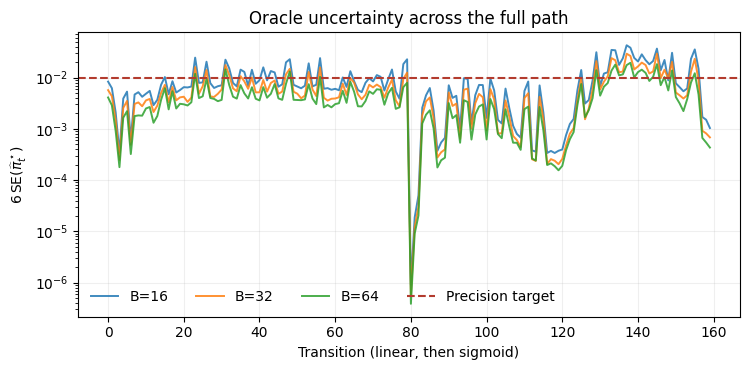

,B,precision pass fraction,median six-SE width,maximum six-SE width
0,16,71.9%,0.0068,0.0429
1,32,81.2%,0.0046,0.0296
2,64,87.5%,0.0033,0.0195


In [3]:
full_convergence = pd.DataFrame(convergence_rows(oracle))
primary_convergence = full_convergence[(full_convergence['sample_size'] == 2048) & (full_convergence['rank'] == 16)]
fig, ax = plt.subplots(figsize=(7.6, 3.8))
for count, frame in primary_convergence.groupby('replicate_count'):
    ordered = frame.sort_values(['schedule', 'step'])
    ax.plot(np.arange(len(ordered)), ordered['six_standard_error_half_width'], linewidth=1.4, alpha=.85, label=f'B={count}')
ax.axhline(.01, color='#b33b2e', linestyle='--', linewidth=1.5, label='Precision target')
ax.set(title='Oracle uncertainty across the full path', xlabel='Transition (linear, then sigmoid)', ylabel=r'$6\,\mathrm{SE}(\widehat\pi_t^\star)$', yscale='log')
ax.grid(alpha=.2)
ax.legend(frameon=False, ncol=4)
fig.tight_layout()
plt.show()
display(pd.DataFrame([{
    'B': int(count),
    'precision pass fraction': frame['precision_pass'].mean(),
    'median six-SE width': frame['six_standard_error_half_width'].median(),
    'maximum six-SE width': frame['six_standard_error_half_width'].max(),
} for count, frame in primary_convergence.groupby('replicate_count')]).style.format({'precision pass fraction': '{:.1%}', 'median six-SE width': '{:.4f}', 'maximum six-SE width': '{:.4f}'}))

## Online estimator versus instantaneous oracle

The online line removes the reconstructed trend-quadratic variance from the instantaneous signal estimate, then applies the deployed $[.01,.95]$ action bounds. It is still a predictable small-data estimate. The black line and band use future truth and repeated high-sample fits offline.

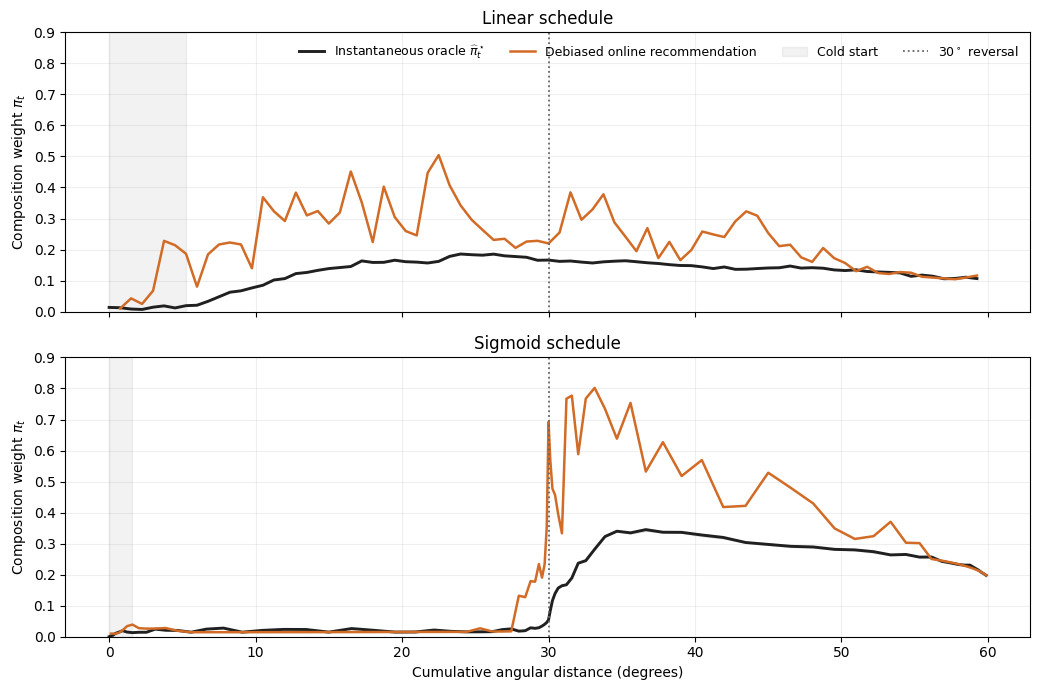

In [4]:
colors = {'online': '#d16b26', 'oracle': '#202020', 'edr': '#2563a6', 'smoothed': '#2f855a'}
fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True, sharey=True)
for ax, schedule in zip(axes, ('linear', 'sigmoid')):
    frame = rows[rows['schedule'] == schedule].sort_values('step')
    ax.fill_between(frame['cumulative_angular_degrees'], frame['oracle_pi_lower_95'], frame['oracle_pi_upper_95'], color=colors['oracle'], alpha=.13, linewidth=0)
    ax.plot(frame['cumulative_angular_degrees'], frame['oracle_pi'], color=colors['oracle'], linewidth=2.1, label=r'Instantaneous oracle $\widehat\pi_t^\star$')
    ax.plot(frame['cumulative_angular_degrees'], frame['debiased_instantaneous_pi'], color=colors['online'], linewidth=1.8, label='Debiased online recommendation')
    cold_end = frame.loc[frame['cold_start'], 'cumulative_angular_degrees'].max()
    ax.axvspan(0, cold_end, color='#888888', alpha=.10, label='Cold start')
    ax.axvline(30, color='#666666', linestyle=':', linewidth=1.3, label=r'$30^\circ$ reversal')
    ax.set(title=f'{schedule.title()} schedule', ylabel=r'Composition weight $\pi_t$', ylim=(0, .9))
    ax.grid(alpha=.2)
axes[-1].set_xlabel('Cumulative angular distance (degrees)')
axes[0].legend(frameon=False, ncol=4, fontsize=9)
fig.tight_layout()
plt.show()

## Realized EDR versus instantaneous oracle

EDR exponentially averages the two risk coefficients before taking their ratio. Its realized action is therefore not expected to equal a noisy instantaneous recommendation. The green line applies that same coefficient-wise discounting to the offline oracle and is shown only to attribute smoothing lag; it is not the target.

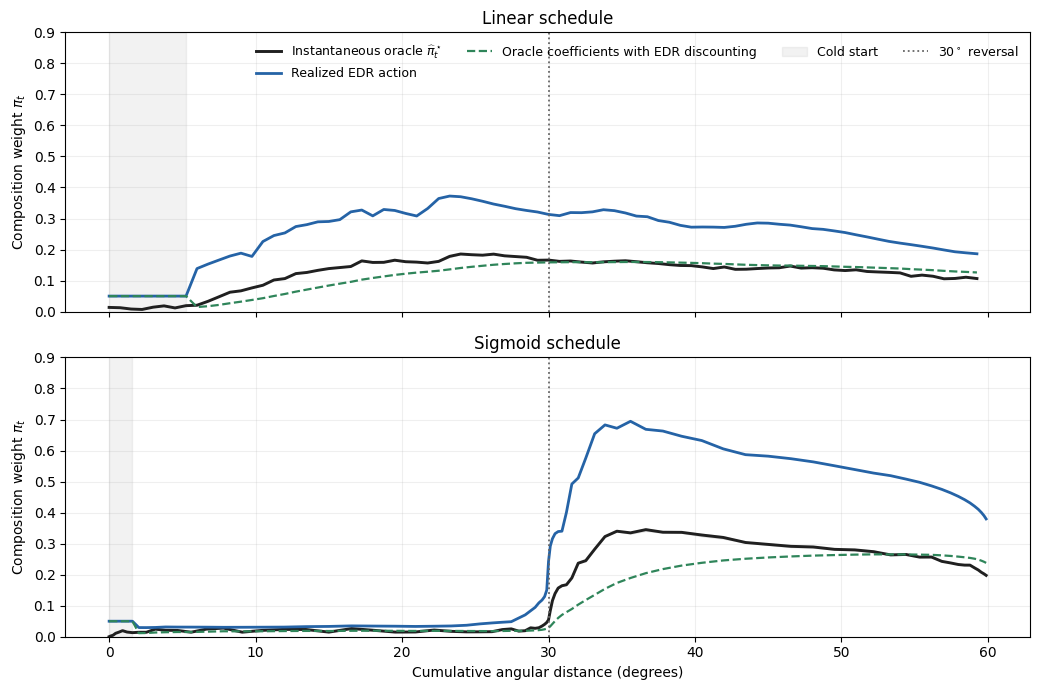

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True, sharey=True)
for ax, schedule in zip(axes, ('linear', 'sigmoid')):
    frame = rows[rows['schedule'] == schedule].sort_values('step')
    ax.fill_between(frame['cumulative_angular_degrees'], frame['oracle_pi_lower_95'], frame['oracle_pi_upper_95'], color=colors['oracle'], alpha=.13, linewidth=0)
    ax.plot(frame['cumulative_angular_degrees'], frame['oracle_pi'], color=colors['oracle'], linewidth=2.1, label=r'Instantaneous oracle $\widehat\pi_t^\star$')
    ax.plot(frame['cumulative_angular_degrees'], frame['realized_edr_pi'], color=colors['edr'], linewidth=2.0, label='Realized EDR action')
    ax.plot(frame['cumulative_angular_degrees'], frame['oracle_smoothed_pi'], color=colors['smoothed'], linestyle='--', linewidth=1.6, label='Oracle coefficients with EDR discounting')
    cold_end = frame.loc[frame['cold_start'], 'cumulative_angular_degrees'].max()
    ax.axvspan(0, cold_end, color='#888888', alpha=.10, label='Cold start')
    ax.axvline(30, color='#666666', linestyle=':', linewidth=1.3, label=r'$30^\circ$ reversal')
    ax.set(title=f'{schedule.title()} schedule', ylabel=r'Composition weight $\pi_t$', ylim=(0, .9))
    ax.grid(alpha=.2)
axes[-1].set_xlabel('Cumulative angular distance (degrees)')
axes[0].legend(frameon=False, ncol=4, fontsize=9)
fig.tight_layout()
plt.show()

In [6]:
display(summaries.style.format({
    'edr_oracle_mae': '{:.4f}',
    'debiased_oracle_mae': '{:.4f}',
    'oracle_smoothing_mae': '{:.4f}',
    'edr_oracle_smoothed_mae': '{:.4f}',
    'consequence_weighted_error_sum': '{:.3f}',
    'consequence_weighted_error_mean': '{:.4f}',
    'oracle_pi_mean': '{:.4f}',
    'oracle_pi_min': '{:.4f}',
    'oracle_pi_max': '{:.4f}',
    'oracle_signal_lift_mean': '{:.4f}',
    'oracle_signal_lift_max': '{:.4f}',
    'edr_oracle_correlation': '{:.3f}',
    'precision_pass_fraction': '{:.1%}',
    'zero_signal_fraction': '{:.1%}',
}))

,schedule,live_transitions,edr_oracle_mae,debiased_oracle_mae,oracle_smoothing_mae,edr_oracle_smoothed_mae,consequence_weighted_error_sum,consequence_weighted_error_mean,oracle_pi_mean,oracle_pi_min,oracle_pi_max,oracle_signal_lift_mean,oracle_signal_lift_max,edr_oracle_correlation,precision_pass_fraction,zero_signal_fraction
0,linear,72,0.1391,0.1071,0.0227,0.1511,6.701,0.0931,0.1374,0.0205,0.1856,0.0026,0.0086,0.925,95.0%,42.5%
1,sigmoid,72,0.1543,0.1317,0.0378,0.1827,15.000,0.2083,0.1457,0.0143,0.3451,0.0026,0.0131,0.988,80.0%,50.0%


## Risk decomposition and path context

The coefficient view shows whether a recommendation is driven by estimated movement $S_t^\star$, retained old uncertainty, or new-batch uncertainty. The path view keeps angle and realized speed visible without crowding the action plots.

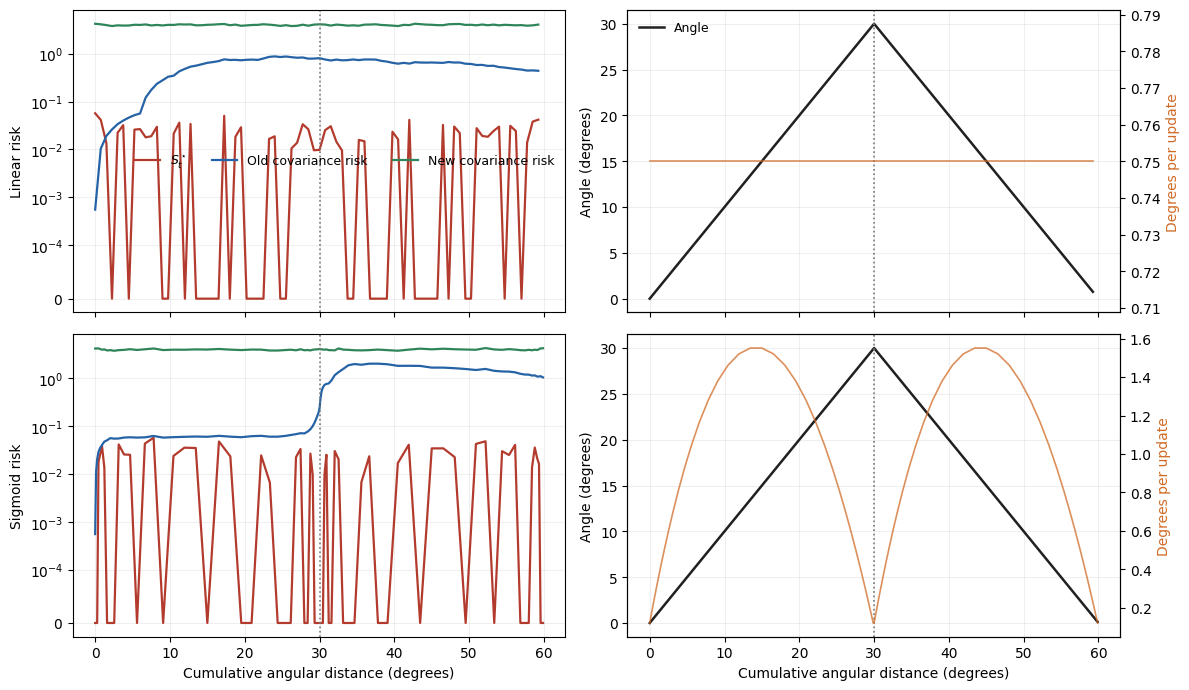

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex='col')
for row_index, schedule in enumerate(('linear', 'sigmoid')):
    frame = rows[rows['schedule'] == schedule].sort_values('step')
    x = frame['cumulative_angular_degrees']
    axes[row_index, 0].plot(x, frame['signal'], color='#b33b2e', linewidth=1.6, label=r'$S_t^\star$')
    axes[row_index, 0].plot(x, frame['old_covariance_risk'], color='#2563a6', linewidth=1.6, label='Old covariance risk')
    axes[row_index, 0].plot(x, frame['new_covariance_risk'], color='#2f855a', linewidth=1.6, label='New covariance risk')
    axes[row_index, 0].set_yscale('symlog', linthresh=1e-4)
    axes[row_index, 0].set_ylabel(f'{schedule.title()} risk')
    axes[row_index, 1].plot(x, frame['angle_degrees'], color='#202020', linewidth=1.8, label='Angle')
    speed_ax = axes[row_index, 1].twinx()
    speed_ax.plot(x, frame['angular_speed_degrees'], color='#d16b26', linewidth=1.2, alpha=.75, label='Speed')
    speed_ax.set_ylabel('Degrees per update', color='#d16b26')
    axes[row_index, 1].set(ylabel='Angle (degrees)')
    for ax in axes[row_index]:
        ax.axvline(30, color='#777777', linestyle=':', linewidth=1.2)
        ax.grid(alpha=.2)
axes[0, 0].legend(frameon=False, ncol=3, fontsize=9)
axes[0, 1].legend(frameon=False, fontsize=9, loc='upper left')
axes[-1, 0].set_xlabel('Cumulative angular distance (degrees)')
axes[-1, 1].set_xlabel('Cumulative angular distance (degrees)')
fig.tight_layout()
plt.show()

## Interpretation

The result is **estimator mismatch with a reference-resolution caveat**, not a failure of coefficient-wise discounting. EDR-to-oracle MAE is `.139` on linear and `.154` on sigmoid. Applying EDR's discounting to the oracle coefficients reduces instantaneous-oracle MAE to `.023` and `.038`, whereas debiasing the online trend estimate reaches only `.107` and `.132`. The online coefficient scale, especially its movement signal, is therefore the dominant observed discrepancy.

The oracle itself resolves little movement contribution at this tessellation: adding $S_t^\star$ over the covariance-only recommendation changes $\pi_t^\star$ by only `.0026` on average on either schedule. Moreover, the fitted reference branch reports exactly zero movement signal on `42.5%` of linear and `50.0%` of sigmoid transitions. Narrow bootstrap intervals quantify local-fit sampling error, but do not remove this optimizer-resolution bias. The estimated oracle is useful for diagnosing scale and lag; it is not precise enough to certify a globally or exactly optimal EDR policy.

A next adaptive-value experiment should predeclare a hold-ramp-hold-return path: hold at $0^\circ$ for 20 updates, ramp to $30^\circ$ over 8 updates, hold for 32 updates, return over 8 updates, then hold for 32 updates. With $m=4$ and the existing eight-step action half-life, the sharp ramps make movement risk observable while each plateau spans four smoothing half-lives. That experiment should follow improved local-reference optimization or a validated coarser signal estimator, rather than being tuned against this trajectory's EDR outcomes.